In [56]:
#Import necessary libraries.
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import mutual_info_classif
from sklearn import metrics
from scipy.stats import entropy

In [58]:
mushroom_df=pd.read_csv("cleaned_secondary_data Final.csv")

In [60]:
mushroom_df.head()#checking on data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
2,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
3,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
4,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w


In [62]:
mushroom_df.shape # reveal number of rows and column of data.

(61070, 21)

In [64]:
def chekNumberOfMissingValues(df):# This function is for checking for number of missing values...
    for col in df.columns:
        print (f"Number of missing values in feature '{col}' is = {df[col].isnull().sum().sum()}\n")

In [66]:
chekNumberOfMissingValues(mushroom_df)

Number of missing values in feature 'class' is = 0

Number of missing values in feature 'cap-diameter' is = 0

Number of missing values in feature 'cap-shape' is = 0

Number of missing values in feature 'cap-surface' is = 14120

Number of missing values in feature 'cap-color' is = 0

Number of missing values in feature 'does-bruise-or-bleed' is = 0

Number of missing values in feature 'gill-attachment' is = 9884

Number of missing values in feature 'gill-spacing' is = 25064

Number of missing values in feature 'gill-color' is = 0

Number of missing values in feature 'stem-height' is = 0

Number of missing values in feature 'stem-width' is = 0

Number of missing values in feature 'stem-root' is = 51538

Number of missing values in feature 'stem-surface' is = 38124

Number of missing values in feature 'stem-color' is = 0

Number of missing values in feature 'veil-type' is = 57892

Number of missing values in feature 'veil-color' is = 53656

Number of missing values in feature 'has-ring' 

In [68]:
# dropping the features that has a lot of missing values...
mushroom_df=mushroom_df.drop('gill-spacing',axis=1)
mushroom_df=mushroom_df.drop('stem-root',axis=1)
mushroom_df=mushroom_df.drop('stem-surface',axis=1)
mushroom_df=mushroom_df.drop('veil-type',axis=1)
mushroom_df=mushroom_df.drop('veil-color',axis=1)
mushroom_df=mushroom_df.drop('spore-print-color',axis=1)

In [70]:
mushroom_df.head() #recheck on the data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,w,16.95,17.09,w,t,g,d,w
1,p,15.26,x,g,o,f,e,w,16.95,17.09,w,t,g,d,w
2,p,16.60,x,g,o,f,e,w,17.99,18.19,w,t,g,d,u
3,p,14.07,x,g,o,f,e,w,17.80,17.74,w,t,g,d,w
4,p,14.17,f,h,e,f,e,w,15.77,15.98,w,t,p,d,w


In [72]:
#Here we handle the missing values with mode...
def replace_missing_with_mode(df, column_name):
    mode_value = df[column_name].mode()[0]
    df.fillna({column_name:mode_value}, inplace=True)
    return df

In [74]:
chekNumberOfMissingValues(mushroom_df)

Number of missing values in feature 'class' is = 0

Number of missing values in feature 'cap-diameter' is = 0

Number of missing values in feature 'cap-shape' is = 0

Number of missing values in feature 'cap-surface' is = 14120

Number of missing values in feature 'cap-color' is = 0

Number of missing values in feature 'does-bruise-or-bleed' is = 0

Number of missing values in feature 'gill-attachment' is = 9884

Number of missing values in feature 'gill-color' is = 0

Number of missing values in feature 'stem-height' is = 0

Number of missing values in feature 'stem-width' is = 0

Number of missing values in feature 'stem-color' is = 0

Number of missing values in feature 'has-ring' is = 0

Number of missing values in feature 'ring-type' is = 2471

Number of missing values in feature 'habitat' is = 0

Number of missing values in feature 'season' is = 0



In [76]:
mushroom_df = replace_missing_with_mode(mushroom_df, "cap-surface")
mushroom_df = replace_missing_with_mode(mushroom_df, "gill-attachment")
mushroom_df = replace_missing_with_mode(mushroom_df, "ring-type")

In [78]:
chekNumberOfMissingValues(mushroom_df)

Number of missing values in feature 'class' is = 0

Number of missing values in feature 'cap-diameter' is = 0

Number of missing values in feature 'cap-shape' is = 0

Number of missing values in feature 'cap-surface' is = 0

Number of missing values in feature 'cap-color' is = 0

Number of missing values in feature 'does-bruise-or-bleed' is = 0

Number of missing values in feature 'gill-attachment' is = 0

Number of missing values in feature 'gill-color' is = 0

Number of missing values in feature 'stem-height' is = 0

Number of missing values in feature 'stem-width' is = 0

Number of missing values in feature 'stem-color' is = 0

Number of missing values in feature 'has-ring' is = 0

Number of missing values in feature 'ring-type' is = 0

Number of missing values in feature 'habitat' is = 0

Number of missing values in feature 'season' is = 0



In [80]:
mushroom_df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,15.26,x,g,o,f,e,w,16.95,17.09,w,t,g,d,w
1,p,15.26,x,g,o,f,e,w,16.95,17.09,w,t,g,d,w
2,p,16.60,x,g,o,f,e,w,17.99,18.19,w,t,g,d,u
3,p,14.07,x,g,o,f,e,w,17.80,17.74,w,t,g,d,w
4,p,14.17,f,h,e,f,e,w,15.77,15.98,w,t,p,d,w


In [82]:
#Here we will encode the data from string to int
from sklearn.preprocessing import LabelEncoder
def encode_labels(df,column_name):
    label_encoder = LabelEncoder()
    df[column_name]=label_encoder.fit_transform(df[column_name])
    return df

In [84]:
#here we change the class data to binary which 1 mean poisons and 0 mean edible
mushroom_df['class']=np.where(mushroom_df['class']=='p',1,0) 

In [86]:
mushroom_df=encode_labels(mushroom_df,"cap-shape")
mushroom_df=encode_labels(mushroom_df,"cap-surface")
mushroom_df=encode_labels(mushroom_df,"cap-color")
mushroom_df=encode_labels(mushroom_df,"does-bruise-or-bleed")
mushroom_df=encode_labels(mushroom_df,'gill-attachment')
mushroom_df=encode_labels(mushroom_df,"gill-color")
mushroom_df=encode_labels(mushroom_df,"stem-color")
mushroom_df=encode_labels(mushroom_df,"has-ring")
mushroom_df=encode_labels(mushroom_df,"ring-type")
mushroom_df=encode_labels(mushroom_df,"habitat")
mushroom_df=encode_labels(mushroom_df,"season")

In [88]:
mushroom_df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,10,16.95,17.09,11,1,2,0,3
1,1,15.26,6,2,6,0,2,10,16.95,17.09,11,1,2,0,3
2,1,16.60,6,2,6,0,2,10,17.99,18.19,11,1,2,0,2
3,1,14.07,6,2,6,0,2,10,17.80,17.74,11,1,2,0,3
4,1,14.17,2,3,1,0,2,10,15.77,15.98,11,1,5,0,3


In [90]:
#for Z-score normalization
def z_score_normalize(df, column_name):
    df[column_name] = stats.zscore(df[column_name])
    return df

In [92]:
mushroom_df['cap-diameter']=(mushroom_df['cap-diameter']*100).astype(int)

In [94]:
mushroom_df['stem-width']=(mushroom_df['stem-width']*100).astype(int)

In [96]:
z_score_normalize(mushroom_df,"stem-height")

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,1526,6,2,6,0,2,10,3.076441,1709,11,1,2,0,3
1,1,1526,6,2,6,0,2,10,3.076441,1709,11,1,2,0,3
2,1,1660,6,2,6,0,2,10,3.385026,1819,11,1,2,0,2
3,1,1407,6,2,6,0,2,10,3.328650,1773,11,1,2,0,3
4,1,1417,2,3,1,0,2,10,2.726316,1598,11,1,5,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61065,1,118,5,7,11,0,3,2,-0.786805,622,12,0,1,0,0
61066,1,127,2,7,11,0,3,2,-1.009342,543,12,0,1,0,0
61067,1,127,5,7,11,0,3,2,-0.807575,637,12,0,1,0,2
61068,1,124,2,7,11,0,3,2,-0.896590,544,12,0,1,0,2


In [98]:
#Split the class from the data for training and testing
X = mushroom_df.drop('class', axis=1)
y = mushroom_df['class'] 

In [100]:
#split the data randomly for train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
clf = sklearn.tree.DecisionTreeClassifier()

In [118]:
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [120]:
model = SelectFromModel(clf, prefit=True)

In [122]:
X_new = model.transform(X)

C:\Users\abdul\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [124]:
selected_features = X.columns[model.get_support()]
print(selected_features)

Index(['cap-surface', 'gill-attachment', 'gill-color', 'stem-height',
       'stem-width', 'stem-color'],
      dtype='object')


In [126]:
mushroom_df=mushroom_df.drop('cap-diameter',axis=1)
mushroom_df=mushroom_df.drop('cap-shape',axis=1)
mushroom_df=mushroom_df.drop('cap-color',axis=1)
mushroom_df=mushroom_df.drop('does-bruise-or-bleed',axis=1)
mushroom_df=mushroom_df.drop('has-ring',axis=1)
mushroom_df=mushroom_df.drop('habitat',axis=1)
mushroom_df=mushroom_df.drop('season',axis=1)

In [128]:
mushroom_df.head()

,class,cap-surface,gill-attachment,gill-color,stem-height,stem-width,stem-color,ring-type
0,1,2,2,10,3.076441,1709,11,2
1,1,2,2,10,3.076441,1709,11,2
2,1,2,2,10,3.385026,1819,11,2
3,1,2,2,10,3.328650,1773,11,2
4,1,3,2,10,2.726316,1598,11,5


In [130]:
mushroom_df.to_csv('MushroomDataCleand.csv', index=False)

In [132]:
y_pred = clf.predict(X_test)

In [134]:
print(f'the accuracy: {metrics.accuracy_score(y_test, y_pred)}')
print(f'the precision: {metrics.precision_score(y_test, y_pred)}')
print(f'the recall: {metrics.recall_score(y_test, y_pred)} ')

the accuracy: 0.9928770263631898
the precision: 0.9937024018746339
the recall: 0.9935568897349538 


In [136]:
Cleand_X = mushroom_df.drop('class', axis=1)
Cleand_y = mushroom_df['class']

In [138]:
def information_gain(data, feature, target):
    target_entropy = entropy(data[target].value_counts(normalize=True))

    unique_values = data[feature].unique()
    weighted_entropy = 0
    for value in unique_values:
        subset = data[data[feature] == value]
        subset_entropy = entropy(subset[target].value_counts(normalize=True))
        weighted_entropy += (len(subset) / len(data)) * subset_entropy

    information_gain = target_entropy - weighted_entropy

    return information_gain

In [140]:
for feature in mushroom_df.columns[1:]:  # Exclude the target variable
    ig = information_gain(mushroom_df, feature, 'class')
    print(f"Information Gain of {feature}: {ig:.4f}")

Information Gain of cap-surface: 0.0260
Information Gain of gill-attachment: 0.0254
Information Gain of gill-color: 0.0187
Information Gain of stem-height: 0.0598
Information Gain of stem-width: 0.1005
Information Gain of stem-color: 0.0420
Information Gain of ring-type: 0.0273


In [141]:
Cleand_X_train, Cleand_X_test, Cleand_y_train, Cleand_y_test = train_test_split(Cleand_X, Cleand_y, test_size=0.2, random_state=42)#split the data randomly for tain and test

In [144]:
Cleand_clf= sklearn.tree.DecisionTreeClassifier(max_depth=3)

In [146]:
Cleand_clf.fit(Cleand_X_train, Cleand_y_train)

DecisionTreeClassifier(max_depth=3)

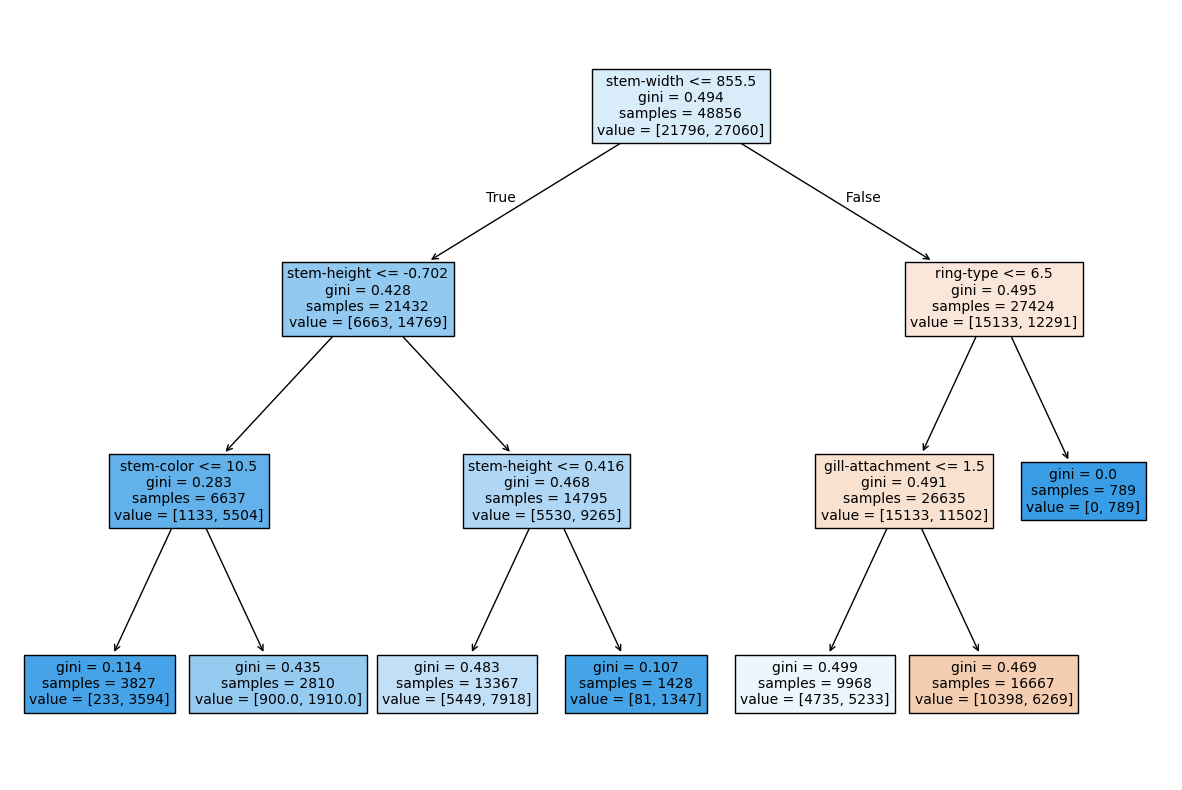

In [150]:
plt.figure(figsize=(15, 10))
sklearn.tree.plot_tree(Cleand_clf, feature_names=Cleand_X.columns, filled=True)
plt.show()